In [3]:
!pwd

/Users/edmundo/Documents/GitHub/numts_primate_t2t/konkel/longer_flanks


## (1) Filter by K-mer Dissimilarity score

In [4]:
import pandas as pd

def filter_by_dissimilarity(flank_size, kd_threshold,
                            input_file_path='expanded_matches_similarity_results.tab',
                            output_file_path='kmerFilter_expanded_matches_similarity_results.tab'):
    """
    Reads a tab-delimited input file, filters the DataFrame to include only rows where 'Hit_Dissimilarity' is greater than 
    or equal to the specified threshold, and saves the filtered DataFrame to a tab-delimited file.

    Parameters:
    - input_file_path (str): The path to the input tab-delimited file. Default is 'expanded_matches_similarity_results.tab'.
    - threshold (float): The threshold value for 'Hit_Dissimilarity'. Default is 0.5.
    - output_file_path (str): The file path to save the filtered DataFrame. Default is 'filtered_data.tab'.

    Returns:
    - DataFrame: A filtered DataFrame containing only rows with 'Hit_Dissimilarity' >= threshold.
    """
    # Read the input data file.
    df = pd.read_table(f"results_{flank_size}bp/expanded_matches_similarity_results.flanks{flank_size}.tab")
    
    # Filter the DataFrame based on the 'Hit_Dissimilarity' column.
    df_filtered = df[df['Hit_Dissimilarity'] <= kd_threshold]
    
    # Save the filtered DataFrame to a tab-delimited file.
    df_filtered.to_csv( f"results_{flank_size}bp/kmerFilter_expanded_matches_similarity_results.flanks{flank_size}.tab" , sep='\t', index=False)
    
    return df_filtered

# Example usage:
df_sim = filter_by_dissimilarity(flank_size=500, kd_threshold=0.8)
df_sim


,Query_Species,NUMT,NUMT_info,Loci,DB_Species,Matches,Counts,Hit_Dissimilarity,Hit_Similarity,Query_CommonName,DB_CommonName,List_Index
0,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,mGorGor1,+::chr10_mat_hsa12:23259200-23260484,1,0.000000,1.000000,Gorilla,Gorilla,0
1,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,mPanPan1,+::chr10_mat_hsa12:13182882-13184157,1,0.214623,0.785377,Gorilla,Bonobo,0
2,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,mPanTro3,+::chr10_hap1_hsa12:14784981-14786261,1,0.191038,0.808962,Gorilla,Chimpanzee,0
3,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,mPonAbe1,+::chr10_hap1_hsa12:7775770-7777060,1,0.455975,0.544025,Gorilla,Sorang,0
4,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,mPonPyg2,+::chr10_hap1_hsa12:7795410-7796725,1,0.485063,0.514937,Gorilla,Borang,0
...,...,...,...,...,...,...,...,...,...,...,...,...
42867,CHM13,CHM13_numt779,NUMT_140bp_80%,-::NC_060948.1:11666771-11666911,CHM13,+::NC_060946.1:6364733-6365894,4,0.423759,0.576241,Human,Human,2
42868,CHM13,CHM13_numt779,NUMT_140bp_80%,-::NC_060948.1:11666771-11666911,CHM13,+::NC_060948.1:11666271-11667411,4,0.000000,1.000000,Human,Human,3
42869,CHM13,CHM13_numt780,NUMT_145bp_71%,+::NC_060948.1:19778589-19778734,mPonAbe1,+::chrY_hap2_hsaY:8446208-8447246,1,0.548985,0.451015,Human,Sorang,0
42870,CHM13,CHM13_numt780,NUMT_145bp_71%,+::NC_060948.1:19778589-19778734,mPonPyg2,+::chrY_hap2_hsaY:8322876-8323915,1,0.533098,0.466902,Human,Borang,0


### NUMTs in a Query species aligning to self and other species
- Bonobo to Bonobo
- Bonobo NUMTs aligning to Chimp
- Bonobo NUMTs aligning to Pongo

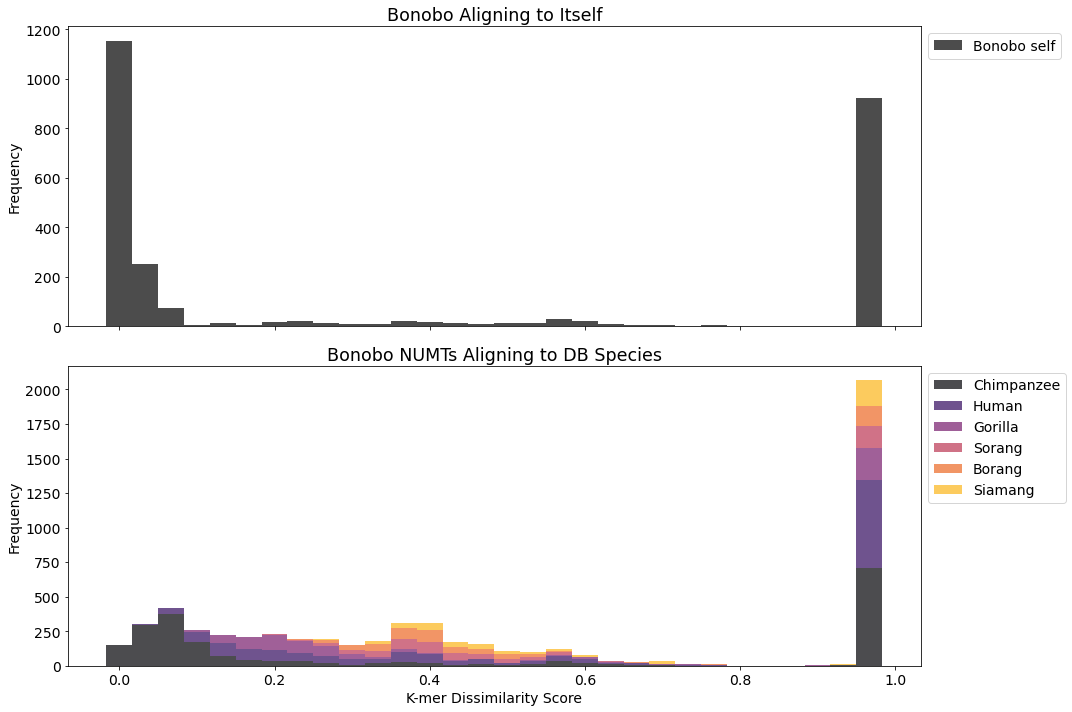

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_hist_stacked(ax, *dfs, column='Hit_Dissimilarity', labels=None, colors=None):
    '''
    Plots stacked histogram of score (default: K-mer Dissimilarity) on a given axis.
    Accepts multiple DFs as input.
    '''
    bins = 30
    max_range = max(df[column].max() for df in dfs) 
    if max_range < 0.4:
        max_range = 0.5
    hist_range = (0, max_range)

    hists = []
    for df in dfs:
        hist, bin_edges = np.histogram(df[column], bins=bins, range=hist_range)
        hists.append(hist)

    width = np.diff(bin_edges)
    bottom = np.zeros(bins)
    
    if labels is None:
        labels = [f'Category {i+1}' for i in range(len(dfs))]
    
    if colors is None:
        # Generate a dark-to-light color palette.
        cmap = plt.get_cmap('inferno') # You can choose any colormap you like.
        colors = [cmap(i / len(dfs)) for i in range(len(dfs))]

    for hist, label, color in zip(hists, labels, colors):
        ax.bar(bin_edges[:-1], hist, width, bottom=bottom, label=label, color=color, alpha=0.7)
        bottom += hist

    tick_size = 14
    title_size = tick_size * 1.25
    
    ax.set_ylabel('Frequency', fontsize=tick_size)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=tick_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_size)

def plot_query_vs_db(flank_size=500, kd_threshold=1, query_species='Bonobo', db_species=['Bonobo', 'Chimpanzee', 'Human', 'Gorilla', 'Sorang', 'Borang','Siamang']):
    """
    Filters BLAT matches based on the specified query species and alignment species, 
    then plots stacked histograms of NUMTs aligned to each specified DB species on subplots.
    
    If the query species aligns with itself, that alignment is plotted separately.
    """
    # Filter the data based on the K-mer dissimilarity threshold.
    df = filter_by_dissimilarity(flank_size=flank_size,threshold=kd_threshold)
    df = df[['NUMT', 'Query_CommonName', 'DB_CommonName', 'Hit_Dissimilarity']]
    
    # Filter for the specified query species
    df = df[df['Query_CommonName'] == query_species]
    
    # Separate dataframes for self-alignment and other species
    df_self = df[df['DB_CommonName'] == query_species]
    df_others = df[df['DB_CommonName'].isin(db_species) & (df['DB_CommonName'] != query_species)]
    
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)
    
    # Define font sizes
    tick_size = 14
    title_size = tick_size * 1.25

    # Plot self-alignment if exists
    if not df_self.empty:
        plot_hist_stacked(axes[0], df_self, labels=[f'{query_species} self'], colors=['black'])
        axes[0].set_title(f'{query_species} Aligning to Itself', fontsize=title_size)
    else:
        axes[0].axis('off')  # Hide the subplot if there's no data

    # Create lists to store dataframes and labels for other species
    dfs = []
    labels = []

    # Iterate through the db_species list and filter the DataFrame for other species
    for species in db_species:
        if species != query_species:
            df_species = df_others[df_others['DB_CommonName'] == species]
            if not df_species.empty:
                dfs.append(df_species)
                labels.append(f'{species}')

    # Plot stacked histogram using the filtered dataframes for other species
    if dfs:
        plot_hist_stacked(axes[1], *dfs, labels=labels)
        axes[1].set_title(f'{query_species} NUMTs Aligning to DB Species', fontsize=title_size)
    
    axes[1].set_xlabel('K-mer Dissimilarity Score', fontsize=tick_size)
    plt.tight_layout()
    plt.show()

plot_query_vs_db(query_species='Bonobo')


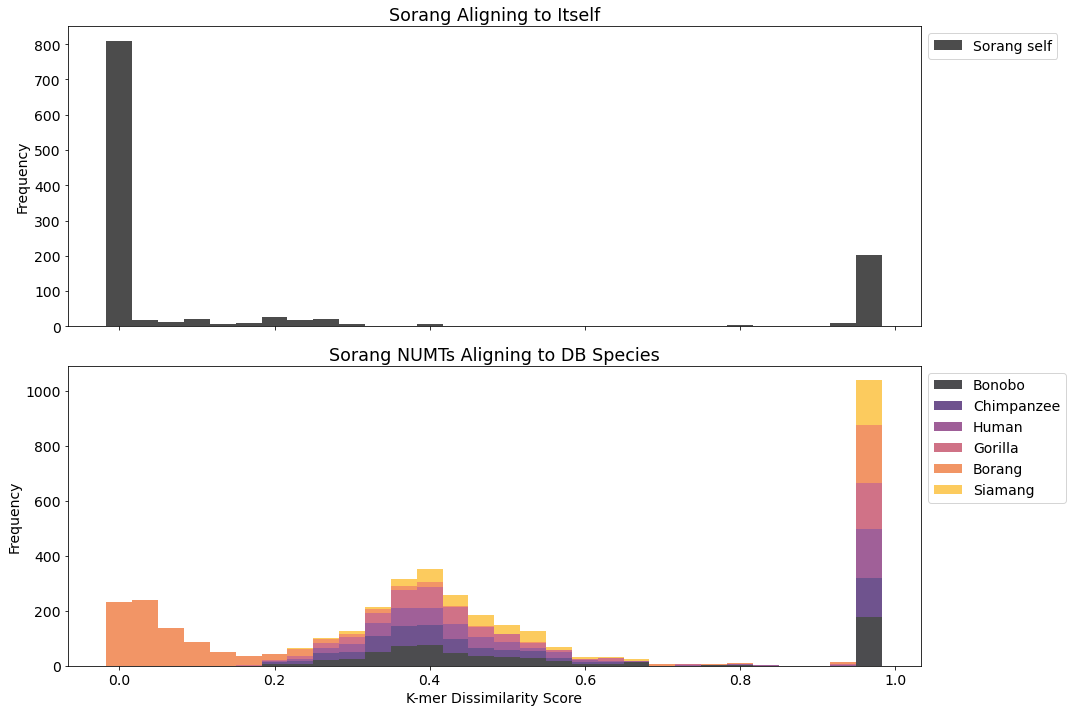

In [7]:
plot_query_vs_db(query_species='Sorang')

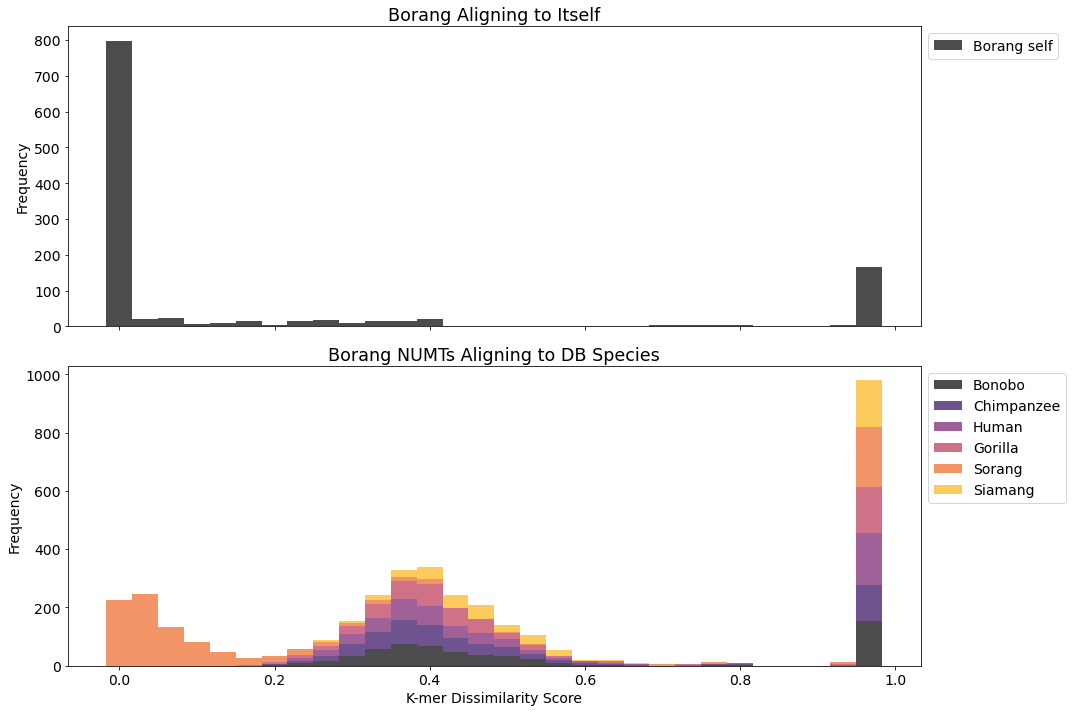

In [8]:
plot_query_vs_db(query_species='Borang')